Data types that comprise smaller pieces are called **compound data types**.

A string is a compound data type because it is comprised of smaller strings each containing one character.

# **Working with the parts of a string**

The indexing operator (Python uses square brackets to enclose the index) selects a single character substring from a string:

In [ ]:
fruit = "banana"
m = fruit[1]

The expression `fruit[1]` selects character number 1 from `fruit`, and creates a new string containing just this one character. The variable `m` refers to the result. When we display `m`, we could get a surprise:

In [ ]:
print(m)

a


Computer scientists always start counting from zero! The letter at subscript position zero of `"banana"` is `b`. So at position [1] we have the letter a.

If we want to access the zero-eth letter of a string, we just place 0, or any expression that evaluates to 0, in between the brackets:

In [ ]:
m = fruit[0]
print(m)

b


The expression in brackets is called an **index**. An index specifies a member of an ordered collection, in this case the collection of characters is the string. The index indicates which one you want, hence the name. It can be any integer expression.

We can use `enumerate` to visualize the indices:

In [ ]:
fruit = "banana"
#enumerate(fruit)
list(enumerate(fruit))


[(0, 'b'), (1, 'a'), (2, 'n'), (3, 'a'), (4, 'n'), (5, 'a')]

It is important to note that indexing returns a **string** - Python has no special type for a single character. It is just a string of length 1.

# **Getting the length of a string**

The `len` function, when applied to a string, returns the number of characers in a string

In [ ]:
fruit = "bananas"
len(fruit)

7

To get the last letter of a string, you might be tempted to try something like this:

In [ ]:
sz = len(fruit)
last = fruit[sz] #fruit[]

IndexError: ignored

That won't work. It causes a runtime error `IndexError: string index out of range`. The reason is that there is no character at index position 6 in `"banana"`. Because we start counting at zero, the six indexes are numbered 0 to 5. To get the last character, we have to subtract 1 from the length of the `fruit`

In [ ]:
sz = len(fruit)
last = fruit[sz-1]

Alternatively, we can use **negative indices**, which count backward from the end of the string. The expression `fruit[-1]` yields the last letter, `fruit[-2]` yields the second to last, and so on.

# **Traversing a string using a `for` loop**

A lot of computations involve processing a string one character at a time. Often they start at the beginning, select each character in turn, do something to it, and continue until the end. This pattern of processing is called a **traversal**. One way to encode a traversal is with a `while` statement:

In [ ]:
ix = 0
while ix < len(fruit):
    letter = fruit[ix]
    print(letter)
    ix += 1
print(ix)

b
a
n
a
n
a
s
7


This loop traverses the string and displays each letter on a line by itself. The loop condition is `ix < len(fruit)`, so when `ix` is equal to the length of the string, the condition is false, and the body of the loop is not executed. The last character accessed is the one with the index `len(fruit)-1`, which is the last character in the string.

Another way to do this is using Python's `for` loop

In [ ]:
for c in fruit: #("b","a","n","a", "n", "a", "s")
    print(c)

b
a
n
a
n
a
s


Each time through the loop, the next character in the string is assigned to the variable `c`. The loop continues until no characters are left. Here we can see the expressive power the `for` loop gives us compared to the while loop when traversing a string.

The following example shows how to use concatenation and a `for` loop to generate an abecedarian series. Abecedarian refers to a series or list in which the elements appear in alphabetical order. For example, in Robert McCloskey’s book *Make Way for Ducklings*, the names of the ducklings are Jack, Kack, Lack, Mack, Nack, Ouack, Pack, and Quack. This loop outputs these names in order:

In [ ]:
prefixes = "JKLMNOPQ"
suffix = "ack"

for p in prefixes:
    if p == "O" or p == "Q":
       print(p + "u" + suffix)
    else:
        print(p + suffix)



Jack
Kack
Lack
Mack
Nack
Ouack
Pack
Quack


Of course, that’s not quite right because Ouack and Quack are misspelled. You’ll fix this as a separate exercise.

# **Slicing a string**

A substring of a string is obtained by taking a **slice**.

In [ ]:
s = "Pirates of the Caribbean"
print(s[0:7])

Pirates


In [ ]:
print(s[11:14])

the


In [ ]:
print(s[15:24])

Caribbean


The operator `[n:m]` returns the part of the string from the n’th character to the m’th character, including the first but excluding the last. This behavior makes sense if you imagine the indices pointing between the characters, as in the following diagram:

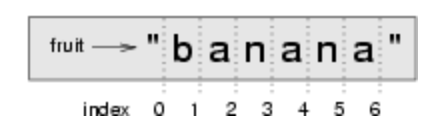

If you imagine this as a piece of paper, the slice operator `[n:m]` copies out the part of the paper between the `n` and `m` positions. Provided `m` and `n` are both within the bounds of the string, your result will be of length `(m-n)`.

Three tricks are added to this: if you omit the first index (before the colon), the slice starts at the beginning of the string (or list). If you omit the second index, the slice extends to the end of the string (or list). Similarly, if you provide value for n that is bigger than the length of the string (or list), the slice will take all the values up to the end. (It won’t give an “out of range” error like the normal indexing operation does.) Thus:

In [ ]:
fruit = "banana"
fruit[:-4]

'ba'

In [ ]:
fruit[3:]

'ana'

In [ ]:
fruit[3:999]

'ana'

# **Comparing strings**

The comparison operators work on strings. To see if two strings are equal:

In [ ]:
word = "banana"

if word == "banana":
    print("Yes, we have no bananas!")

Yes, we have no bananas!


In [ ]:
"ac" > "aB"

True

Other comparison operations are useful for putting words in *lexicographical* order:

In [ ]:
if word < "banana":
    print("Your word, " + word + ", comes before banana.")
elif word > "banana":
    print("Your word, " + word + ", comes after banana.")
else:
    print("Yes, we have no bananas!")

This is similar to the alphabetical order you would use with a dictionary, except that all the uppercase letters come before all the lowercase letters. As a result:

`Your word, Zebra, comes before banana.`

A common way to address this problem is to convert strings to a standard format, such as all lowercase, before performing the comparison.

# **Strings are immutable**

It is tempting to use the [] operator on the left side of an assignment, with the intention of changing a character in a string. For example:

In [ ]:
greeting = "Hello, world!"
greeting[0] = 'J'            # ERROR!
print(greeting)

TypeError: ignored

Instead of producing the output `Jello, world!`, this code produces the runtime error `TypeError: 'str' object does not support item assignment`.

Strings are **immutable**, which means you can’t change an existing string. The best you can do is create a new string that is a variation on the original:

In [ ]:
greeting = "Hello, world!"
new_greeting = "J" + greeting[1:]
print(new_greeting)

The solution here is to concatenate a new first letter onto a slice of greeting. This operation has no effect on the original string.

# **The `in` and `not in` operators**

The `in` operator tests for membership. When both of the arguments to `in` are strings, `in` checks whether the left argument is a substring of the right argument.

In [ ]:
"p" in "apple"

True

In [ ]:
"i" in "apple"

False

In [ ]:
"ap" in "apple"

True

In [ ]:
"pa" in "apple"

False

Note that a string is a substring of itself, and the empty string is a substring of any other string.

In [ ]:
"a" in "a"

True

In [ ]:
"apple" in "apple"

True

In [ ]:
"" in "a"

True

In [ ]:
"" in "apple"

True

The `not in` operator returns the logical opposite results of `in`:



In [ ]:
"x" not in "apple"

True

Combining the `in` operator with string concatenation using `+`, we can write a function that removes all the vowels from a string:

In [ ]:
def remove_vowels(s):
    vowels = "aeiouAEIOU"
    consonants = ""

    for x in s: # "msuiitians"
        print(f"current character {x}")
        if x not in vowels:
            consonants += x
            print(f"consonants: {consonants}")
    return consonants

remove_vowels("msuiitians")

current character m
consonants: m
current character s
consonants: ms
current character u
current character i
current character i
current character t
consonants: mst
current character i
current character a
current character n
consonants: mstn
current character s
consonants: mstns


'mstns'

In [ ]:
remove_vowels("aAbEefIijOopUus")

current character a
current character A
current character b
consonants: b
current character E
current character e
current character f
consonants: bf
current character I
current character i
current character j
consonants: bfj
current character O
current character o
current character p
consonants: bfjp
current character U
current character u
current character s
consonants: bfjps


'bfjps'

# **Looping and counting**

The following program counts the number of times the letter `a` appears in a string, and is another example of the counter pattern introduced in "Counting digits"

In [ ]:
def count_letter(letter, text):
    count = 0
    for c in text:
        if c == letter:
            count += 1 #count = count / 1
    return(count)

count_letter("a", "banana")

3

# **The `split` method**

One of the most useful methods on a strings is the `split` method. It splits a single mutli-word string into a list of individual words, removing all the whitespace between them. (Whitespace means any tabs, newlines or spaces). This allows us to read input as a single string, and split into words.

In [ ]:
ss = "Well I : never did : said Alice"
wds = ss.split(":")
new_wds = ""
for i in wds:
    print(i)
    new_wds += i
print(new_wds)
newer_wds = new_wds.split()
"*".join(newer_wds)
#wdss = wds.split(":")
#wdss

Well I 
 never did 
 said Alice
Well I  never did  said Alice


'Well*I*never*did*said*Alice'

# **Cleaning up your strings**

We'll often work with strings that contain punctuation, or tab and newline characters especially, when we read our text from files or from the Internet. But if we're writing a program, say, to count word frequencies or check the spelling of each word, we would prefer to strip off these unwanted characters.

Here is on example of how to strip punctuation from a string. Remember that strings are immutable, so we cannot change the string with the punctuation - we need to traverse the original string and create a new string, omitting any punctutation:

In [ ]:
punctuation = "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"

def remove_punctuation_v1(s):
    s_sans_punct = ""
    for letter in s:
        if letter not in punctuation:
            s_sans_punct += letter #s_sans_punct = s_sans_punct + letter
    return s_sans_punct

Setting up that first assignment is messy and error-prone. Fortunately, the Python string module already does it for us. So we will make a slight improvement to this program — we’ll import the `string` module and use its definition:

In [ ]:
import string



def remove_punctuation_v2(s):
    s_without_punct = ""
    for letter in s:
        if letter not in string.punctuation:
            s_without_punct += letter
    return s_without_punct

remove_punctuation_v2('"Well, I never did!", said Alice.')

'Well I never did said Alice'

In [ ]:
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


# **The string format method**

In [ ]:
x = 5
print(f"hello {x}")
print("hello " + str(x))
print("hello", x)

hello 5
hello 5
hello 5


The easiest and most powerful way to format a string in Python 3 is to use the `format` method. To see how this works, let’s start with a few examples:

In [ ]:
s1 = "His name is {0}!".format("Arthur")
print(s1)

In [ ]:
name = "Alice"
age = 10
s2 = "I am {1} and I am {0} years old.".format(age, name)
print(s2)
s3 = f"I am {name} and I am {age} years old."
print(s3)

I am Alice and I am Alice years old.
I am Alice and I am 10 years old.


In [ ]:
n1 = 4
n2 = 5
s3 = "2**10 = {0} and {1} * {2} = {3:f}".format(2**10, n1, n2, n1 * n2)
print(s3)

The template string contains *placeholders*, `... {0} ... {1} ... {2} ...` etc. The format method substitutes its arguments into the place holders. The numbers in the place holders are indexes that determine which argument gets substituted.

Each of the replacement fields can also contain a **format specification** — it is always introduced by the `:` symbol. This modifies how the substitutions are made into the template, and can control things like:

* whether the field is aligned to the left `<`, center `^`, or right `>`
* the width allocated to the field within the result string (a number like `10`)
* the type of conversion (we’ll initially only force conversion to float, f, as we did in the code above)
* if the type conversion is a float, you can also specify how many decimal places are wanted (typically, `.2f` is useful for working with currencies to two decimal places.)



In [ ]:
print("Pi to three decimal places is {0:.2f}".format(3.1415926))

Pi to three decimal places is 3.14


In [ ]:
n1 = "Paris"
n2 = "Whitney"
n3 = "Hilton"

print("|||{0:<15}|||{1:^15}|||{2:>15}|||Born in {3}|||".format(n1,n2,n3,1981))

|||Paris          |||    Whitney    |||         Hilton|||Born in 1981|||


You can have multiple placeholders indexing the same argument, or perhaps even have extra arguments that are not referenced at all:

In [ ]:
letter = """
Dear {0} {2}.
 {0}, I have an interesting money-making proposition for you!
 If you deposit $10 million into my bank account, I can
 double your money ...
"""

print(letter.format("Paris", "Whitney", "Hilton"))
print(letter.format("Bill", "Henry", "Gates"))


Dear Paris Hilton.
 Paris, I have an interesting money-making proposition for you!
 If you deposit $10 million into my bank account, I can
 double your money ...


Dear Bill Gates.
 Bill, I have an interesting money-making proposition for you!
 If you deposit $10 million into my bank account, I can
 double your money ...



Below is an example of a program that prints out a table of various powers of the numbers from 1 to 10 and then format it using the string formatting method above.

In [ ]:
layout = "{0:>4}{1:^7}{2:>8}{3:>12}{4:>24}{5:>48}"

print(layout.format("i", "i**2", "i**3", "i**5", "i**10", "i**20"))
for i in range(1, 11):
    print(layout.format(i, i**2, i**3, i**5, i**10, i**20))

   i i**2      i**3        i**5                   i**10                                           i**20
   1   1          1           1                       1                                               1
   2   4          8          32                    1024                                         1048576
   3   9         27         243                   59049                                      3486784401
   4  16         64        1024                 1048576                                   1099511627776
   5  25        125        3125                 9765625                                  95367431640625
   6  36        216        7776                60466176                                3656158440062976
   7  49        343       16807               282475249                               79792266297612001
   8  64        512       32768              1073741824                             1152921504606846976
   9  81        729       59049              3486784401         

In [ ]:
for i in range(1, 6):
    print(i)

1
2
3
4
5
